<div dir="rtl" style="text-align:center; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:28px; font-weight:bold; margin:20px 0; color:#2e86de;">
آزمون فرض
</div>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
df = pd.read_csv("Divar.csv")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4696\1381234337.py:1: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Divar.csv")


<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۱: با توجه به رشد مهاجرت افراد از شهر‌های کوچکتر به کلان‌شهر‌ها و تراکم جمعیت در این نواحی، تصور می‌شود که میانگین مساحت خانه‌های مسکونی در کلان‌شهرها نسبت به شهر‌های کوچک و روستاها کمتر است. آیا مجموعه داده‌ این فرضیه را پشتیبانی می‌کند؟
</div>

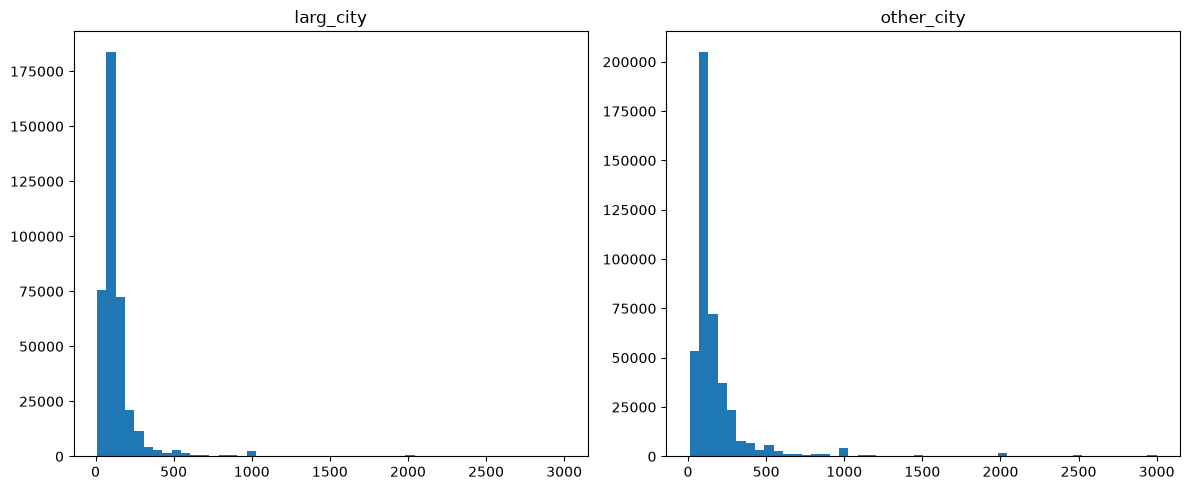

72770226263.0 
 0.0


In [ ]:
data = pd.read_csv('Divar.csv')
city = pd.read_csv('iran_city_classification.csv')
city.head()
new = data.merge(city,left_on='city_slug',right_on='نام شهر',how='left')
new = new.drop(columns=['نام شهر'])
new = new[(new['cat2_slug']=='residential-sell') |(new['cat2_slug']=='residential-rent') ]
larg_city = new[new['دسته‌بندی']=='کلان‌شهر']
other_city = new[new['دسته‌بندی']!='کلان‌شهر']
larg_city['building_size'].describe()
larg_city = larg_city.drop(larg_city[larg_city['building_size']<10].index)
other_city = other_city.drop(other_city[other_city['building_size']<10].index)
larg_city = larg_city.drop(larg_city[larg_city['building_size']>3000].index)
other_city = other_city.drop(other_city[other_city['building_size']>3000].index)
# رسم هیستوگرام برای دیدن نرمال بودن یا نه
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(larg_city['building_size'], bins=50)
ax[0].set_title('larg_city')
ax[1].hist(other_city['building_size'], bins=50)
ax[1].set_title('other_city')
plt.tight_layout()
plt.show()
large = larg_city['building_size'].dropna()
other = other_city['building_size'].dropna()
# نرمال نبود یا باید بازه رو کوچیکتر کنم که به نرمال نزدیک بششه که کار درستی نیست توضیح میدم چرا
# فرض صفر: m_large_city >= m_other
# فرض الترنتیو:m_large_city < m_other
u , p_value = stats.mannwhitneyu(large,other,alternative='less')
print(u,'\n',p_value)
# other_city_mean = other_city['building_size'].describe()

In [ ]:
compare_u = len(large) * len(other)/2
print(compare_u)
print(u)

84182829627.0
72770226263.0


<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۲: «قدیما خونه‌ها دلبازتر بود!» برای بررسی این فرضیه، آیا میانگین مساحت خانه‌های قدیمی‌ساخت نسبت به خانه‌های جدید ساخت بیشتر است؟
</div>

In [ ]:
divar_df = pd.read_csv('./Divar.csv')

In [ ]:
divar_df = divar_df.dropna(subset=['construction_year'])

In [ ]:
import re
def extract_number(x):
    if x == 'قبل از ۱۳۷۰':
        return 1369
    return re.findall(r'(\d{4})', x)[0]

In [ ]:
divar_df['construction_year'] = divar_df['construction_year'].apply(extract_number).astype(int)

In [ ]:
old_construction_year = divar_df[divar_df['construction_year'] < 1396]
new_construction_year = divar_df[divar_df['construction_year'] >= 1396]

In [ ]:
q_high_old_land = old_construction_year['land_size'].quantile(0.99)
q_low_old_land = old_construction_year['land_size'].quantile(0.01)
df_clean_old_land = old_construction_year[old_construction_year['land_size'] <= q_high_old_land]
df_clean_old_land = df_clean_old_land[df_clean_old_land['land_size'] >= q_low_old_land]

q_high_new_land = new_construction_year['land_size'].quantile(0.99)
q_low_new_land = new_construction_year['land_size'].quantile(0.01)
df_clean_new_land = new_construction_year[new_construction_year['land_size'] <= q_high_new_land]
df_clean_new_land = df_clean_new_land[df_clean_new_land['land_size'] >= q_low_new_land]

In [ ]:
print(f'old land_size median: {df_clean_old_land['land_size'].median()}')
print(f'old land_size mean  : {df_clean_old_land['land_size'].mean():.2f}')
print(f'old land_size mode  : {stats.mode(df_clean_old_land['land_size'])[0]}')
print('-'*32)
print(f'new land_size median: {df_clean_new_land['land_size'].median()}')
print(f'new land_size mean  : {df_clean_new_land['land_size'].mean():.2f}')
print(f'new land_size mode  : {stats.mode(df_clean_new_land['land_size'])[0]}')

old land_size median: 160.0
old land_size mean  : 231.81
old land_size mode  : 200.0
--------------------------------
new land_size median: 210.0
new land_size mean  : 312.12
new land_size mode  : 200.0


In [ ]:
q_high_old = old_construction_year['building_size'].quantile(0.99)
q_low_old = old_construction_year['building_size'].quantile(0.01)
df_clean_old = old_construction_year[old_construction_year['building_size'] <= q_high_old]
df_clean_old = df_clean_old[df_clean_old['building_size'] >= q_low_old]

q_high_new = new_construction_year['building_size'].quantile(0.99)
q_low_new = new_construction_year['building_size'].quantile(0.01)
df_clean_new = new_construction_year[new_construction_year['building_size'] <= q_high_new]
df_clean_new = df_clean_new[df_clean_new['building_size'] >= q_low_new]

In [ ]:
print(f'old building_size median: {df_clean_old['building_size'].median()}')
print(f'old building_size mean  : {df_clean_old['building_size'].mean():.2f}')
print(f'old building_size mode  : {stats.mode(df_clean_old['building_size'])[0]}')
print('-'*32)
print(f'new building_size median: {df_clean_new['building_size'].median()}')
print(f'new building_size mean  : {df_clean_new['building_size'].mean():.2f}')
print(f'new building_size mode  : {stats.mode(df_clean_new['building_size'])[0]}')

old building_size median: 85.0
old building_size mean  : 117.69
old building_size mode  : 100.0
--------------------------------
new building_size median: 105.0
new building_size mean  : 141.99
new building_size mode  : 100.0


<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۳: اشتن سند تجاری (یا هر نوع سند ملکی) در املاک به این معنی است که سند مالکیت معتبر، رسمی و قانونی برای ملک تجاری دارید. این سند نشان می‌دهد که شما صاحب قانونی ملک تجاری هستید و می‌توانید از حقوق مالکیت آن استفاده کنید. بررسی کنید که آیا داشتن سند تجاری(has_business_deed) بر میانگین قیمت فروش ملک تجاری ارتباط معناداری دارد؟ 
</div>

<div dir="rtl" align="right">


در سؤال سوم از بخش **آزمون فرض**، از ما خواسته شده است بررسی کنیم که آیا **داشتن سند تجاری بر میانگین قیمت فروش املاک تجاری اثر معناداری دارد یا خیر**.

برای بررسی این موضوع، ابتدا املاک **تجاری** را از داده‌ها انتخاب کردیم و با حذف **قیمت‌های پرت**، داده‌ها را برای انجام آزمون آماری آماده کردیم. سپس املاک تجاری را بر اساس وضعیت سند به دو گروه **دارای سند تجاری** و **فاقد سند تجاری** تقسیم کردیم.

در مرحله بعد، برای هر دو گروه، **میانگین** و **میانه قیمت فروش** را محاسبه کردیم تا تفاوت قیمت بین دو گروه را بررسی کنیم.

سپس برای بررسی معناداری آماری تفاوت بین دو گروه، از دو آزمون آماری استفاده کردیم:

* **Welch's t-test** برای بررسی تفاوت میانگین قیمت فروش دو گروه
* **Mann-Whitney U test** برای بررسی تفاوت توزیع قیمت فروش دو گروه، به‌ویژه در شرایطی که فرض‌های آزمون t مناسب نباشند.

در نهایت، با بررسی نتایج این آزمون‌ها و **مقدار p-value**، مشخص کردیم که آیا تفاوت مشاهده‌شده در قیمت فروش املاک دارای سند تجاری و فاقد سند تجاری از نظر آماری **معنادار** است یا خیر.

</div>


In [ ]:
# انتخاب املاک تجاری
commercial_sales = df[
    (df['cat2_slug'] == 'commercial-sell')
    & df['price_value'].notna()
    & (df['price_value'] > 10000000)
].copy()

#  حذف ۵٪ داده‌های پرت قیمتی از بالا و پایین برای تحلیل دقیق‌تر
q_low = commercial_sales['price_value'].quantile(0.05)
q_high = commercial_sales['price_value'].quantile(0.95)
commercial_clean = commercial_sales[
    (commercial_sales['price_value'] >= q_low)
    & (commercial_sales['price_value'] <= q_high)
].copy()

#  جداسازی دو گروه: دارای سند تجاری و بدون سند تجاری
group_with_deed = commercial_clean[
    commercial_clean['has_business_deed'] == True
]['price_value'].dropna()

group_without_deed = commercial_clean[
    commercial_clean['has_business_deed'] == False
]['price_value'].dropna()

#  میانگین و میانه به میلیارد تومان
mean_with = group_with_deed.mean() / 1e9
median_with = group_with_deed.median() / 1e9

mean_without = group_without_deed.mean() / 1e9
median_without = group_without_deed.median() / 1e9

#  اجرای آزمون‌های آماری
# Welch's t-test
t_stat, p_val_ttest = stats.ttest_ind(
    group_with_deed, group_without_deed, equal_var=False
)

# Mann-Whitney U
u_stat, p_val_mw = stats.mannwhitneyu(
    group_with_deed, group_without_deed, alternative='two-sided'
)

#  خروجی و گزارش نتایج
print('=== آمار توصیفی (بر حسب میلیارد تومان) ===')
print(f'تعداد املاک با سند تجاری: {len(group_with_deed):,}')
print(f'میانگین: {mean_with:.2f}B | میانه: {median_with:.2f}B')
print('-' * 40)
print(f'تعداد املاک بدون سند تجاری: {len(group_without_deed):,}')
print(f'میانگین: {mean_without:.2f}B | میانه: {median_without:.2f}B')

print('\n=== نتایج آزمون‌های فرضیه ===')
print(f'Welch t-test P-value: {p_val_ttest:.4e}')
print(f'Mann-Whitney U P-value: {p_val_mw:.4e}')

alpha = 0.05
if p_val_ttest < alpha or p_val_mw < alpha:
    print(
        '\nنتیجه تحلیل: فرضیه صفر (H0) رد می‌شود.'
    )
    print(
        'داشتن سند تجاری (has_business_deed) ارتباط معناداری از نظر آماری با قیمت فروش ملک دارد.'
    )
else:
    print(
        '\nنتیجه تحلیل: دلیل کافی برای رد فرضیه صفر وجود ندارد (تفاوت قیمت‌ها معنادار نیست).'
    )

=== آمار توصیفی (بر حسب میلیارد تومان) ===
تعداد املاک با سند تجاری: 12,097
میانگین: 7.10B | میانه: 4.00B
----------------------------------------
تعداد املاک بدون سند تجاری: 11,963
میانگین: 6.20B | میانه: 3.30B

=== نتایج آزمون‌های فرضیه ===
Welch t-test P-value: 1.8664e-19
Mann-Whitney U P-value: 1.8946e-33

نتیجه تحلیل: فرضیه صفر (H0) رد می‌شود.
داشتن سند تجاری (has_business_deed) ارتباط معناداری از نظر آماری با قیمت فروش ملک دارد.


با توجه به نتایج به دست آمده هر دو آزمون ارتباط معناداری بین داشتن سند تجاری و قیمت ملک تجاری وجود دارد

در ادامه نمودار جعبه‌ای داده‌های قیمت دو گروه املاک دارای سند تجاری و بدون سند تجاری ترسیم شده‌اند

C:\Users\Data.Norahand\AppData\Local\Temp\ipykernel_18980\1222762469.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


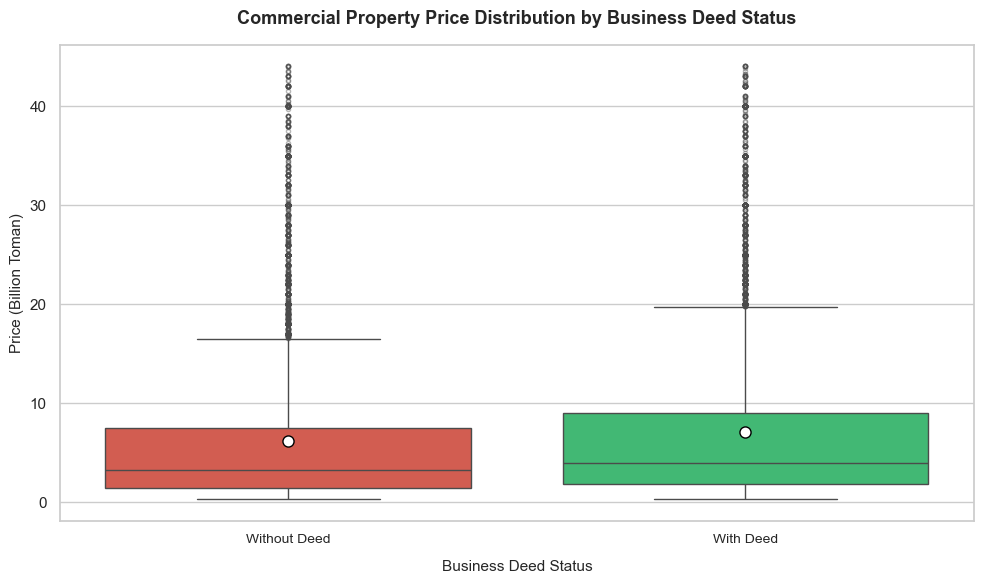

In [ ]:
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))


commercial_clean['price_billion'] = commercial_clean['price_value'] / 1e9


ax = sns.boxplot(
    data=commercial_clean,
    x='has_business_deed',
    y='price_billion',
    palette=['#e74c3c', '#2ecc71'],  
    showmeans=True,  
    meanprops={
        'marker': 'o',
        'markerfacecolor': 'white',
        'markeredgecolor': 'black',
        'markersize': '8',
    },
    flierprops={
        'marker': 'o',
        'markersize': 3,
        'alpha': 0.4,
    },  
)


plt.title(
    'Commercial Property Price Distribution by Business Deed Status',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Business Deed Status', fontsize=11, labelpad=10)
plt.ylabel('Price (Billion Toman)', fontsize=11)


plt.xticks([0, 1], ['Without Deed', 'With Deed'], fontsize=10)

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۴: در دسته‌بندی امکانات موجود در آگهی‌ها می‌توانیم آنها را به دو دسته‌ی امکانات لاکچری(استخر، باربیکیو، سونا، جکوزی) و امکانات غیر لاکچری تقسیم کنیم. فرضیه‌ی ما این است که میانگین مبلغ قیمت برای وجود ویژگی‌های لاکچری افزایش چشم‌گیری دارد. اما آیا این میانگین برای وجود امکانات غیرلاکچری نیز تفاوت معناداری دارد؟
</div>

In [4]:
df_price = df.dropna(subset=['price_value']).copy()

luxury_features = ['has_pool', 'has_barbecue', 'has_sauna', 'has_jacuzzi']
df_price['has_luxury'] = df_price[luxury_features].any(axis=1)

non_luxury_features = [
    'has_water',
    'has_warm_water_provider',
    'has_electricity',
    'has_gas',
    'has_heating_system',
    'has_cooling_system',
    'has_restroom',
    'has_security_guard',
    'has_balcony',
    'has_elevator',
    'has_warehouse',
    'has_parking'
]
df_price['has_non_luxury'] = df_price[non_luxury_features].any(axis=1)

In [5]:
print(df_price.groupby('has_luxury')['price_value'].agg(['count', 'mean', 'median']))
print(df_price.groupby('has_non_luxury')['price_value'].agg(['count', 'mean', 'median']))

             count          mean        median
has_luxury                                    
False       562055  1.742976e+10  2.835500e+09
True          6291  1.161241e+10  2.950000e+09
                 count          mean        median
has_non_luxury                                    
False           143354  2.245211e+10  1.550000e+09
True            424992  1.564956e+10  3.200000e+09


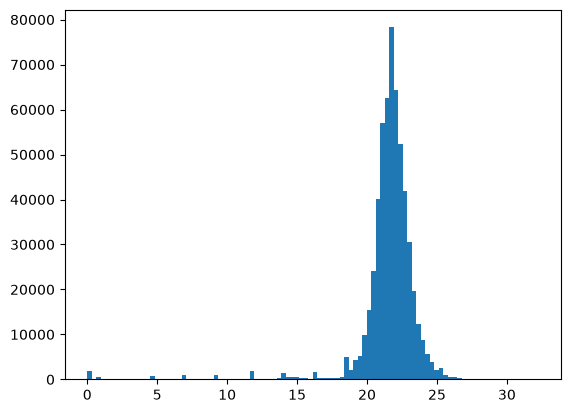

In [6]:
plt.hist(np.log1p(df_price['price_value']), bins=100)
plt.show()

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
نمودار توزیع لگاریتم قیمت (log1p) را نشان می‌دهد. توزیع کاملاً نرمال نیست: بدنه‌ی اصلی داده (تقریباً بین ۱۸ تا ۲۶) شکلی نسبتاً زنگوله‌ای دارد، اما یک دسته‌ی کوچک و جدا در سمت چپ (بین ۰ تا ۱۵) نیز دیده می‌شود که باعث می‌شود توزیع به‌صورت <b>دو‌مودی (bimodal)</b> و <b>چوله به چپ</b> باشد. همین انحراف از نرمال بودن است که استفاده از آزمون ناپارامتریک Mann-Whitney را به‌جای t-test برای مقایسه‌ی گروه‌ها توجیه می‌کند.
</div>

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
<b>امکانات لاکچری:</b><br>
فرض صفر (H0): توزیع قیمت آگهی‌های دارای امکانات لاکچری و بدون آن یکسان است (تفاوتی وجود ندارد).<br>
فرض مقابل (H1): توزیع قیمت آگهی‌های دارای امکانات لاکچری و بدون آن با هم متفاوت است.
</div>

In [7]:
group_luxury_true = df_price[df_price['has_luxury']]['price_value']
group_luxury_false = df_price[~df_price['has_luxury']]['price_value']

u_stat, p_value = stats.mannwhitneyu(group_luxury_true, group_luxury_false, alternative='two-sided')

print(f"U: {u_stat}, p-value: {p_value}")

U: 1838835768.5, p-value: 4.296161216158544e-08


<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
تفاوت قیمت بین آگهی‌های دارای امکانات <b>لاکچری</b> و بدون آن از نظر آماری معنادار است (U=1838835768.5, p≈4.3×10⁻⁸).
</div>

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
<b>امکانات غیرلاکچری:</b><br>
فرض صفر (H0): توزیع قیمت آگهی‌های دارای امکانات غیرلاکچری و بدون آن یکسان است (تفاوتی وجود ندارد).<br>
فرض مقابل (H1): توزیع قیمت آگهی‌های دارای امکانات غیرلاکچری و بدون آن با هم متفاوت است.
</div>

In [8]:
group_nl_true = df_price[df_price['has_non_luxury']]['price_value']
group_nl_false = df_price[~df_price['has_non_luxury']]['price_value']

u_stat_nl, p_value_nl = stats.mannwhitneyu(group_nl_true, group_nl_false, alternative='two-sided')

print(f"U: {u_stat_nl}, p-value: {p_value_nl}")

U: 39535841395.5, p-value: 0.0


<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
تفاوت قیمت بین آگهی‌های دارای امکانات <b>غیرلاکچری</b> و بدون آن نیز از نظر آماری کاملاً معنادار است (U=39535841395.5, p<0.001)، و با توجه به بزرگ‌تر بودن آماره‌ی U و p-value نزدیک به صفر نسبت به حالت لاکچری، شواهد قوی‌تری برای تفاوت بین دو گروه غیرلاکچری وجود دارد.
</div>